# 02  Intensity tail shift

This notebook tests whether the share of tropical cyclones reaching high intensity has increased since 1988.

A storm is treated as high-intensity if its storm-level peak wind reaches at least 
58.1 m/s. Results are reported separately by basin because cyclone behaviour and data coverage differ regionally.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

# Bootstrap settings
RNG = np.random.default_rng(42)
N_BOOTSTRAP = 1000

MIN_STORMS_PER_YEAR = 3

# Wind thresholds in m/s
THRESHOLD_HIGH = 58.1   # Major hurricane and above

ANALYSIS_BASINS = ['WP', 'EP', 'NA', 'SI', 'SP']

### Risk motivation

For a reinsurer, the key question is whether a larger share of storms is reaching high wind-speed thresholds. That matters because high-wind storms are more likely to drive large claims, even if the total number of storms does not increase.

This notebook therefore focuses on the share of storms with peak wind at or above 58.1 m/s, reported separately by basin. The goal here is to measure whether the historical pattern has changed, not to prove what caused the change.

In [2]:
storms = pd.read_parquet('../data/processed/storms_analysis.parquet')

START_YEAR = 1988
END_YEAR = 2023

storms = storms[
    storms["basin"].isin(ANALYSIS_BASINS)
    & storms["year"].between(START_YEAR, END_YEAR)
].copy()

print(f"Loaded {len(storms):,} storms across {storms['basin'].nunique()} basins")
print(f"Year range: {storms['year'].min()} to {storms['year'].max()}")

basin_counts = (
    storms.groupby('basin')
    .size()
    .reindex(ANALYSIS_BASINS)
    .rename('n_storms')
    .to_frame()
)

display(basin_counts)

Loaded 2,424 storms across 5 basins
Year range: 1988 to 2023


,n_storms
basin,
WP,851
EP,497
NA,411
SI,435
SP,230


### Exploratory period view
Storms grouped into broad periods first, to see whether later periods differ from earlier ones. Error bars show bootstrap 95% CIs.

In [3]:
def bootstrap_fraction(values, n_boot=N_BOOTSTRAP, ci=95, rng=RNG):
    """Bootstrap 95% CI for a binary proportion, returned as percentages."""
    
    values = np.asarray(values, dtype=bool)
    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan
    
    point = values.mean() * 100
    indices = rng.integers(0, n, size=(n_boot, n))
    boot_means = values[indices].mean(axis=1) * 100
    
    alpha = (100 - ci) / 2
    lower = np.percentile(boot_means, alpha)
    upper = np.percentile(boot_means, 100 - alpha)
    return point, lower, upper

In [4]:
# Mark storms that exceed the high-intensity wind threshold

storms["high_intensity"] = storms["peak_wind_ms"] >= THRESHOLD_HIGH

rows = []

for basin in ANALYSIS_BASINS:
    basin_storms = storms[storms["basin"] == basin]
    
    for decade in sorted(basin_storms["decade"].unique()):
        period_storms = basin_storms[basin_storms["decade"] == decade]
        
        # Avoid reporting unstable percentages from very small samples
        if len(period_storms) < 10:
            continue
        
        point, lower, upper = bootstrap_fraction(period_storms["high_intensity"])
        
        rows.append({
            "basin": basin,
            "decade": decade,
            "n_storms": len(period_storms),
            "share": point,
            "ci_lower": lower,
            "ci_upper": upper
        })

decade_summary = pd.DataFrame(rows)

In [5]:
def label_period(decade):
    if decade == 1980:
        return "1988–1989"
    if decade == 2020:
        return "2020–2023"
    return f"{decade}s"


display_table = decade_summary.copy()
display_table["period"] = display_table["decade"].apply(label_period)

display_table["share"] = display_table["share"].round(1)
display_table["95% CI"] = (
    display_table["ci_lower"].round(1).astype(str)
    + "–"
    + display_table["ci_upper"].round(1).astype(str)
)

display_table = display_table[
    ["basin", "period", "n_storms", "share", "95% CI"]
].rename(columns={
    "basin": "Basin",
    "period": "Period",
    "n_storms": "Storms",
    "share": "High-intensity share (%)"
})

display(display_table.style.hide(axis="index"))

Basin,Period,Storms,High-intensity share (%),95% CI
WP,1988–1989,56,5.400000,0.0–10.7
WP,1990s,261,5.700000,3.1–8.8
WP,2000s,230,8.300000,4.8–12.2
WP,2010s,242,15.300000,10.7–19.8
WP,2020–2023,62,12.900000,4.8–21.0
EP,1988–1989,26,15.400000,3.8–30.8
EP,1990s,125,29.600000,22.4–37.6
EP,2000s,133,13.500000,7.5–20.3
EP,2010s,155,27.700000,21.3–34.8
EP,2020–2023,58,25.900000,15.5–37.9


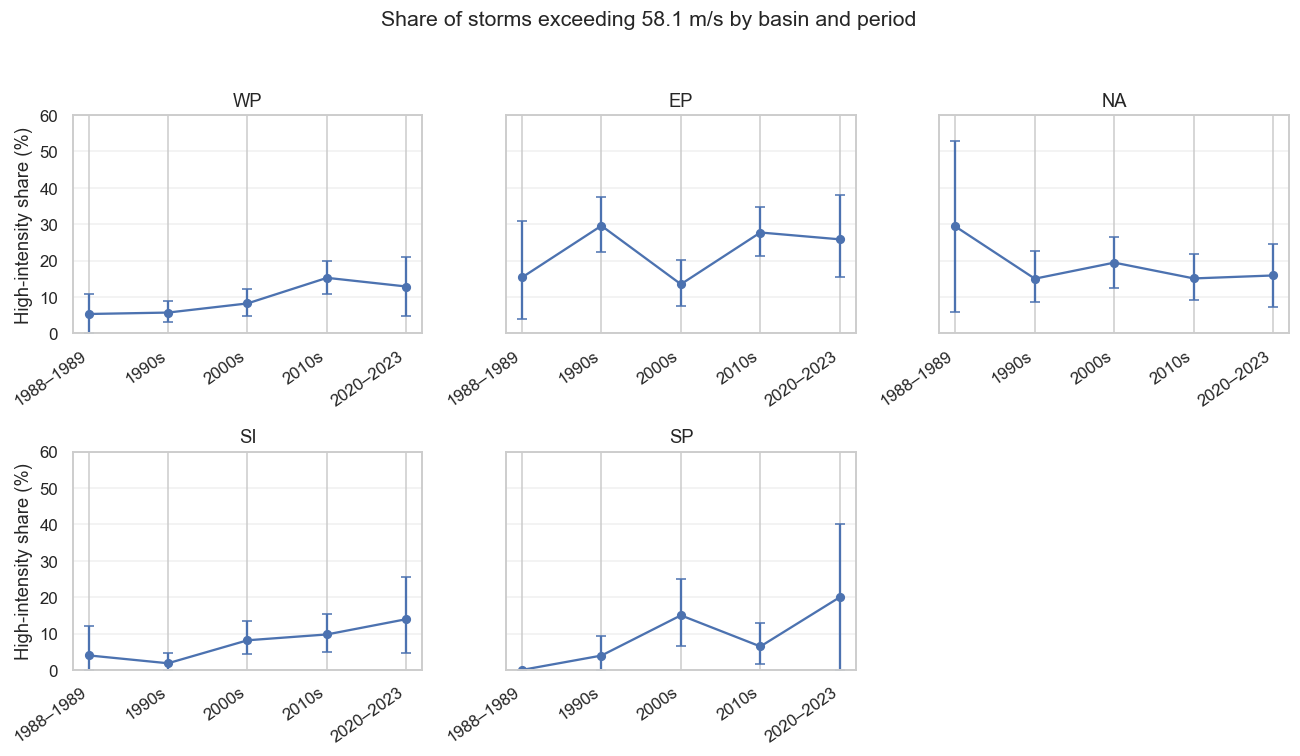

In [6]:
# Plot broad-period high-intensity share with bootstrap confidence intervals

plot_df = decade_summary.copy()
plot_df["period"] = plot_df["decade"].apply(label_period)

period_order = ["1988–1989", "1990s", "2000s", "2010s", "2020–2023"]
x_positions = {period: i for i, period in enumerate(period_order)}
plot_df["x"] = plot_df["period"].map(x_positions)

# Set a common y-axis limit so no confidence intervals are clipped
y_max = np.ceil(plot_df["ci_upper"].max() / 10) * 10

fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 7),
    sharey=True
)

axes = axes.flatten()

for ax, basin in zip(axes, ANALYSIS_BASINS):
    basin_data = plot_df[plot_df["basin"] == basin].sort_values("x")
    
    yerr = np.vstack([
        basin_data["share"] - basin_data["ci_lower"],
        basin_data["ci_upper"] - basin_data["share"]
    ])
    
    ax.errorbar(
        basin_data["x"],
        basin_data["share"],
        yerr=yerr,
        fmt="o-",
        capsize=3,
        linewidth=1.5,
        markersize=5
    )
    
    ax.set_title(basin)
    ax.set_xticks(range(len(period_order)))
    ax.set_xticklabels(period_order, rotation=35, ha="right")
    ax.set_ylim(0, y_max)
    ax.grid(True, axis="y", alpha=0.3)

# Hide unused sixth subplot
axes[-1].axis("off")

axes[0].set_ylabel("High-intensity share (%)")
axes[3].set_ylabel("High-intensity share (%)")

fig.suptitle(
    "Share of storms exceeding 58.1 m/s by basin and period",
    fontsize=14,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

WP and SI look higher in later periods, EP and NA look flatter or noisier, and SP is volatile. 

Because decade bins could hide yearly patterns, and because the first and last periods are incomplete, the formal trend evidence is based on yearly basin-level shares in the next section.

In [7]:
# Yearly high-intensity share by basin
yearly_high = (
    storms
    .groupby(["basin", "year"])
    .agg(
        n_storms=("high_intensity", "size"),
        high_intensity_share=("high_intensity", "mean")
    )
    .reset_index()
)

yearly_high["high_intensity_share"] *= 100

# Remove very small basin-year cells, where one storm can dominate the percentage
yearly_high = yearly_high[
    yearly_high["n_storms"] >= MIN_STORMS_PER_YEAR
].copy()

yearly_high = yearly_high[
    yearly_high["basin"].isin(ANALYSIS_BASINS)
].sort_values(["basin", "year"])

print("Years retained per basin:")
print(yearly_high.groupby("basin").size().reindex(ANALYSIS_BASINS))

Years retained per basin:
basin
WP    36
EP    36
NA    36
SI    36
SP    35
dtype: int64


### Yearly Kendall trend check

The trend test runs on yearly basin-level high-intensity shares. Theil-Sen is the main slope estimate because it is less sensitive to unusual years than OLS. Slopes are reported in percentage points per decade.
OLS is included as a reference. When OLS and Theil-Sen agree on direction, the result is not driven by the slope method. When they disagree, Theil-Sen is used.

In [8]:
trend_results = []

for basin in ANALYSIS_BASINS:
    sub = yearly_high[yearly_high["basin"] == basin].sort_values("year")
    
    if len(sub) < 10:
        continue
    
    x = sub["year"].to_numpy()
    y = sub["high_intensity_share"].to_numpy()
    
    # Rank-based trend check
    tau, p_value = stats.kendalltau(x, y)
    
    # Simple descriptive slope
    ols_result = stats.linregress(x, y)
    ols_decade = ols_result.slope * 10
    
    # Robust median-based slope and confidence interval
    ts_result = stats.theilslopes(y, x, alpha=0.95, method="separate")
    ts_decade = ts_result.slope * 10
    ts_ci_low = ts_result.low_slope * 10
    ts_ci_high = ts_result.high_slope * 10
    
    trend_results.append({
        "Basin": basin,
        "Years": len(sub),
        "Kendall tau": round(tau, 3),
        "p-value": round(p_value, 3),
        "OLS (pp/decade)": round(ols_decade, 2),
        "Theil-Sen (pp/decade)": round(ts_decade, 2),
        "Theil-Sen 95% CI": f"[{round(ts_ci_low, 2)}, {round(ts_ci_high, 2)}]",
    })

trend_table = pd.DataFrame(trend_results)

display(trend_table)

,Basin,Years,Kendall tau,p-value,OLS (pp/decade),Theil-Sen (pp/decade),Theil-Sen 95% CI
0,WP,36,0.348,0.003,3.29,3.86,"[1.22, 5.84]"
1,EP,36,0.027,0.816,0.66,0.00,"[-4.01, 4.76]"
2,NA,36,-0.028,0.814,-0.19,0.00,"[-2.2, 2.33]"
3,SI,36,0.320,0.010,4.43,1.98,"[0.0, 4.78]"
4,SP,35,0.267,0.043,3.68,0.00,"[0.0, 4.29]"


Western Pacific is the clearest finding. Kendall p = 0.003, Theil-Sen +3.9 pp/decade, with a 95% CI that excludes zero.

South Indian shows a smaller upward signal. The Kendall test is significant (p = 0.010), but the Theil-Sen slope of +2.0 pp/decade is less than half the OLS estimate of +4.4, and its CI just touches zero. I report Theil-Sen because the gap between estimators suggests OLS is being pulled upward by a few high-share years.

South Pacific is the sensitivity case. Kendall is significant (p = 0.043), but the Theil-Sen slope is zero. SP has many zero-share years, which pulls the median pairwise slope to zero while leaving Kendall free to pick up an upward tendency in the ranks. The direction may be upward, but the magnitude is not stable enough to act on.


Eastern Pacific and North Atlantic show no meaningful trend. Kendall p-values are above 0.8, and Theil-Sen CIs span zero in both directions.

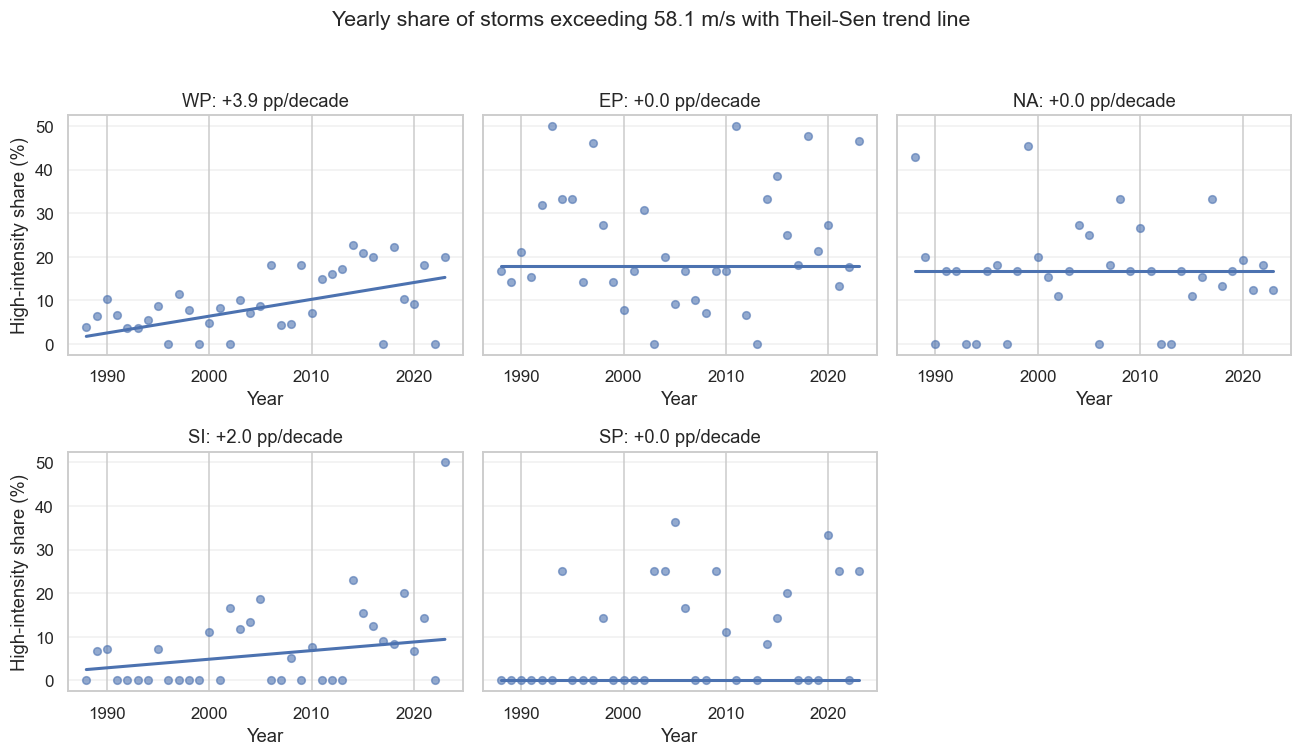

In [9]:
# Yearly high-intensity share with Theil-Sen trend line

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
axes = axes.flatten()

for ax, basin in zip(axes, ANALYSIS_BASINS):
    sub = yearly_high[yearly_high["basin"] == basin].sort_values("year")
    
    x = sub["year"].to_numpy()
    y = sub["high_intensity_share"].to_numpy()
    
    ax.scatter(x, y, alpha=0.6, s=25)
    
    ts = stats.theilslopes(y, x, alpha=0.95, method="separate")
    
    x_line = np.array([x.min(), x.max()])
    y_line = ts.intercept + ts.slope * x_line
    
    ax.plot(x_line, y_line, linewidth=2)
    
    ax.set_title(f"{basin}: {ts.slope * 10:+.1f} pp/decade")
    ax.set_xlabel("Year")
    ax.grid(True, axis="y", alpha=0.3)

axes[-1].axis("off")

axes[0].set_ylabel("High-intensity share (%)")
axes[3].set_ylabel("High-intensity share (%)")

fig.suptitle(
    "Yearly share of storms exceeding 58.1 m/s with Theil-Sen trend line",
    fontsize=14,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

The yearly plots support the trend table with clear upward slope in WP, noisier upward slope in SI, flat lines in EP and NA, and SP flat with many zero years.

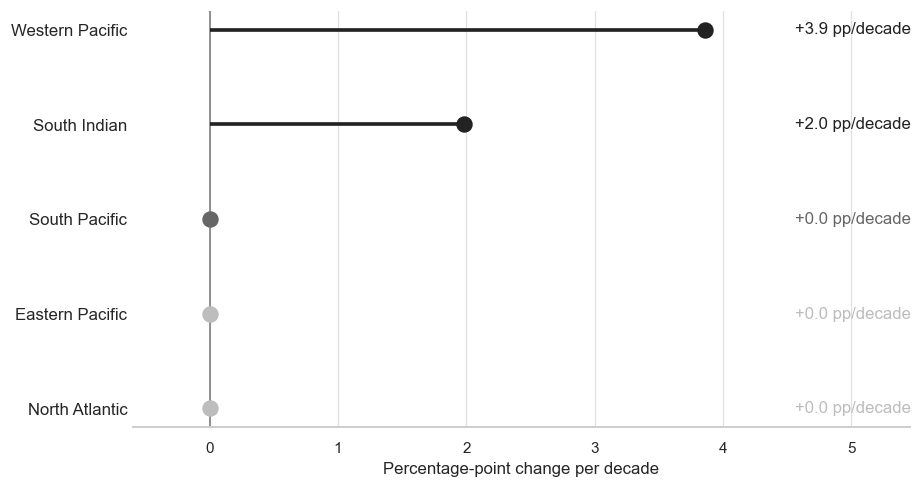

In [10]:
# Final presentation chart based on the Theil-Sen estimates in trend_table
basin_name_map = {
    "WP": "Western Pacific", "SI": "South Indian", "SP": "South Pacific",
    "EP": "Eastern Pacific", "NA": "North Atlantic",
}

plot_df = trend_table.copy()
plot_df["basin"] = plot_df["Basin"].map(basin_name_map)
plot_df["change_pp_per_decade"] = plot_df["Theil-Sen (pp/decade)"]
plot_df["signal"] = np.select(
    [
        (plot_df["p-value"] < 0.05) & (plot_df["change_pp_per_decade"] > 0),
        (plot_df["p-value"] < 0.05) & (plot_df["change_pp_per_decade"] == 0),
    ],
    [
        "clear upward",
        "sensitivity case",
    ],
    default="no meaningful shift"
)

basin_order = [
    "Western Pacific", "South Indian", "South Pacific",
    "Eastern Pacific", "North Atlantic",
]
plot_df["basin"] = pd.Categorical(plot_df["basin"], categories=basin_order, ordered=True)
plot_df = plot_df.sort_values("basin", ascending=False)

color_map = {
    "clear upward": "#222222",
    "sensitivity case": "#666666",
    "no meaningful shift": "#BDBDBD",
}

fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.axvline(0, color="#8A8A8A", linewidth=1.2)

label_x = plot_df["change_pp_per_decade"].max() + 0.7
ax.set_xlim(-0.6, label_x + 0.9)

for _, row in plot_df.iterrows():
    basin = row["basin"]
    x = row["change_pp_per_decade"]
    color = color_map[row["signal"]]
    ax.hlines(y=basin, xmin=min(0, x), xmax=max(0, x), color=color, linewidth=2.4)
    ax.scatter(x, basin, color=color, s=95, zorder=3)
    ax.text(label_x, basin, f"{x:+.1f} pp/decade", va="center", ha="left", fontsize=11, color=color)

ax.set_xlabel("Percentage-point change per decade", fontsize=11)
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(axis="y", length=0, labelsize=11)
ax.tick_params(axis="x", labelsize=10)
ax.grid(axis="x", color="#E0E0E0", linewidth=0.8)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### Conclusion

The high-intensity tail has shifted upward in WP (clearly) and SI (more weakly). SP shows a rank-based upward tendency but a robust slope of zero. EP and NA are flat over 1988–2023.
The shift is regional, not global. Any baseline update should be applied basin by basin rather than as a uniform global adjustment.

WP and SI are where stationary baselines look most questionable for high-intensity risk, so baseline updates should weight recent decades more heavily in those two basins. SP belongs on the watch list rather than the pricing-trigger list. EP and NA show no evidence requiring a basin-specific severity adjustment.

### Limitations

This notebook is diagnostic of past change, not a forecast. The trend tests show whether the high-intensity share has shifted over 1988–2023, but they do not explain what drove the shift or whether it will continue.

The 58.1 m/s cutoff captures only one slice of the intensity distribution. A continuous tail measure, such as peak-wind quantiles or accumulated cyclone energy, could change the picture in basins where the shift is concentrated above or below this threshold. The threshold is useful as a clear high-intensity trigger, but the severity conclusion is conditional on that choice.